## Depth profiles with monthly averages using EasyOneArgoBGCLite data, float 5905103

In [2]:
import numpy as np
from oneargopy.OneArgo import Argo
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.cm as cm # new package for the colorbar
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.ticker import LogLocator, FormatStrFormatter
from matplotlib.colors import LogNorm
import gsw
from tqdm import tqdm
import matplotlib.image as mpimg
import earthaccess
import h5netcdf
import seaborn as sns
import xarray as xr
from matplotlib.patches import Rectangle
import dask
import contourpy

from importlib import reload
import SO_tools as tools; reload(tools)

/opt/anaconda3/envs/IBIS_Project/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'SO_tools' from '/Users/lilah/Documents/IBIS_Project/SO_tools.py'>

In [3]:
df = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data_Summer/EasyOneArgoBGCLite_5905103.csv')

In [4]:
#convert to datetime
df['profile_date'] = pd.to_datetime(df['profile_date'],format = 'mixed',utc=True)
df = df.dropna(subset=["profile_date"]) #drop any cycles with no date or lat/lon 

#create season columns
df["year"] = df["profile_date"].dt.year.astype("Int64")
df["month"] = df["profile_date"].dt.month.astype("Int64")

def assign_season(row):
    m = int(row["month"])
    y = int(row["year"])
    if m >= 9:
        return f"{y}-{y+1}"
    elif m <= 4:
        return f"{y-1}-{y}"
    else:
        return f"{y}"

df["season"] = df.apply(assign_season, axis=1)

In [6]:
df_2 = df[df['season'].isin(['2019-2020'])]
# df_3 = df_2.groupby('month')['chla'].transform(lambda x: x.mean(axis=1))
df_3 = df_2.groupby(['month', 'pressure'])['chla'].mean()

df_4 = df_3.to_frame()

In [7]:
df_plot = df_4.reset_index()

In [8]:
print(df_plot)

     month  pressure      chla
0        1       2.0       NaN
1        1       5.0  0.085900
2        1      10.0  0.130767
3        1      15.0  0.130767
4        1      20.0  0.130767
..     ...       ...       ...
646     12    1000.0  0.002633
647     12    1100.0  0.003167
648     12    1200.0  0.003167
649     12    1300.0  0.002633
650     12    1400.0  0.002400

[651 rows x 3 columns]


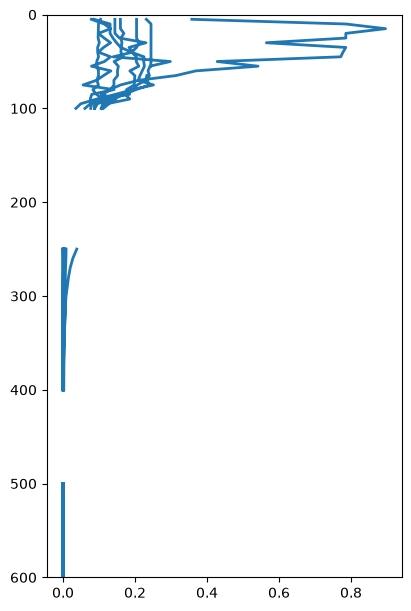

In [9]:
# Create figure and axis
fig = plt.figure(figsize=(4,6), layout='constrained')

# Chlorophyll profile -----------------------------------------------------------------
ax = fig.add_subplot(111)
# date_val = mdates.date2num(group['DATE'].iloc[0])
# color = cmap(norm(date_val))
ax.plot(df_plot['chla'], df_plot['pressure'], lw=2)

# ax.set_xlim(0, 7)
ax.set_ylim(0, 600)
ax.invert_yaxis()
# ax.set_xlabel('Chl-a (mg m$^{-3}$)', fontsize=12)
# ax.set_ylabel('Pressure (dbar)', fontsize=12)
# ax.set_title(f'WMO {str(WMOID)} Chl-a Profiles', fontsize=14)
